In [374]:
import pandas as pd

Load datasets

In [375]:
oecd = pd.read_csv("oecd_bli_2015.csv", thousands=',')
gdp = pd.read_csv("gdp_per_capita.csv", thousands=',')
oecd.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals,BASE_PER,Base period
0,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUT,Austria,3_1,Households living in overcrowded conditions,PT_HH,Percentage of households,...,10.234319,NaN,A,Normal value,0,Units,2,Two,_Z,NaN
1,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUT,Austria,3_1,Households living in overcrowded conditions,PT_HH,Percentage of households,...,10.712656,NaN,A,Normal value,0,Units,2,Two,_Z,NaN
2,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUT,Austria,3_1,Households living in overcrowded conditions,PT_HH,Percentage of households,...,11.594034,NaN,A,Normal value,0,Units,2,Two,_Z,NaN
3,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUT,Austria,3_1,Households living in overcrowded conditions,PT_HH,Percentage of households,...,11.928257,NaN,A,Normal value,0,Units,2,Two,_Z,NaN
4,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUT,Austria,3_1,Households living in overcrowded conditions,PT_HH,Percentage of households,...,12.688166,NaN,A,Normal value,0,Units,2,Two,_Z,NaN


In [376]:
gdp.sample(5)

,Entity,Code,Year,GDP per capita,GDP per capita (Annotations)
11429,Nepal,NPL,2008,2021.1540,NaN
6585,Germany,DEU,1944,9698.0000,NaN
18953,Togo,TGO,2003,1114.4639,NaN
14578,Portugal,PRT,1664,1613.3934,NaN
1457,Bolivia,BOL,1921,1849.0000,NaN


keep only life satisfaction

In [377]:
life_sat = oecd[oecd["Measure"] == "Life satisfaction"]

In [378]:
print(oecd["OBS_VALUE"])

0       10.234319
1       10.712656
2       11.594034
3       11.928257
4       12.688166
          ...    
8223     5.800000
8224     5.900000
8225     6.000000
8226     6.100000
8227     6.000000
Name: OBS_VALUE, Length: 8228, dtype: float64


keep necessary columns

In [379]:
life_sat = life_sat[["Reference area", "OBS_VALUE"]]
life_sat = life_sat.rename(columns={
    "Reference area": "Country",
    "OBS_VALUE": "Life satisfaction"
})

In [380]:
life_sat.groupby("Country").size()

Country
Australia           2
Austria             6
Belgium             6
Bulgaria            6
Canada             14
Colombia            5
Croatia             6
Czechia             6
Denmark             6
Estonia             6
Finland             6
France              6
Germany             5
Greece              6
Hungary             6
Iceland             2
Ireland             6
Italy               6
Japan               6
Korea              10
Latvia              6
Lithuania           6
Luxembourg          6
Mexico              1
Netherlands         6
New Zealand         5
Norway              6
Poland              6
Portugal            6
Romania             6
Slovak Republic     6
Slovenia            6
Spain               6
Sweden              6
Switzerland         6
Türkiye             6
United Kingdom     12
dtype: int64

In [381]:
life_sat = life_sat.drop_duplicates(subset="Country")

In [382]:
print(len(life_sat))

37


clean GDP dataset

In [383]:
gdp.columns = gdp.columns.str.strip()

In [384]:
print(gdp.head())
print(gdp.columns.tolist())

        Entity Code  Year  GDP per capita GDP per capita (Annotations)
0  Afghanistan  AFG  1950          1156.0                          NaN
1  Afghanistan  AFG  1951          1170.0                          NaN
2  Afghanistan  AFG  1952          1189.0                          NaN
3  Afghanistan  AFG  1953          1240.0                          NaN
4  Afghanistan  AFG  1954          1245.0                          NaN
['Entity', 'Code', 'Year', 'GDP per capita', 'GDP per capita (Annotations)']


In [385]:
# keep only 2015 GDP
gdp = gdp[gdp["Year"] == 2015]

In [386]:
gdp = gdp[["Entity", "GDP per capita"]]
gdp = gdp.rename(columns={"Entity": "Country", "GDP per capita": "GDP per capita (USD)"})

In [387]:
print(gdp.head())
print(gdp.columns.tolist())

         Country  GDP per capita (USD)
65   Afghanistan              1928.000
144      Albania             10192.529
220      Algeria             14007.894
293       Angola              8319.567
446    Argentina             19423.666
['Country', 'GDP per capita (USD)']


In [388]:
gdp.groupby("Country").size()

Country
Afghanistan    1
Albania        1
Algeria        1
Angola         1
Argentina      1
              ..
World          1
Yemen          1
Yugoslavia     1
Zambia         1
Zimbabwe       1
Length: 178, dtype: int64

Merge

In [389]:
merge = pd.merge(life_sat, gdp, on="Country")

Reorder

In [390]:
merge = merge[["Country", "GDP per capita (USD)", "Life satisfaction"]]

In [391]:
merge.head()

,Country,GDP per capita (USD),Life satisfaction
0,Australia,48145.530,7.500000
1,Austria,41255.715,7.810006
2,Belgium,39160.324,7.528975
3,Canada,43761.527,8.000000
4,Colombia,13237.291,8.262497


In [392]:
merge.to_csv("life_gdp_dataset.csv", index=False)

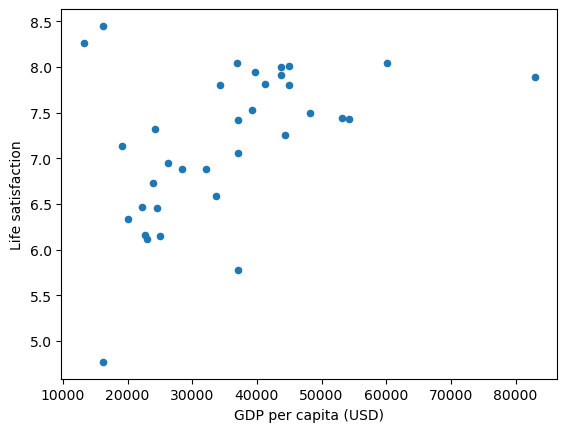

In [393]:
import matplotlib.pyplot as plt

merge.plot(kind="scatter", x="GDP per capita (USD)", y="Life satisfaction")
plt.show()